In [2]:
 #  Q1 & Q2: Setup and Reproducibility
# Import required libraries following ISLP conventions
import numpy as np, pandas as pd, random, torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from pytorch_lightning import seed_everything
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
%pip install torchinfo
from torchinfo import summary
%pip install torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from pathlib import Path

# Set seeds for reproducibility across all random number generators
# This ensures consistent results across runs
seed_everything(57, workers=True)
torch.use_deterministic_algorithms(True, warn_only=True)

print("✓ All libraries imported and seeds set for reproducibility")


Note: you may need to restart the kernel to use updated packages.


Seed set to 57


Note: you may need to restart the kernel to use updated packages.
✓ All libraries imported and seeds set for reproducibility


In [3]:
# Q1 Part A:m Data Preparation - Load and splito Wage dataset
# Load the Wage dataset fromd ISLP package
from ISLP import load_data
Wage = load_data('Wage')


# Select features and target as specified

from ISLP.models import ModelSpec as MS
model = MS(Wage.columns.drop('wage'), intercept=False)
X = model.fit_transform(Wage).to_numpy() 

Y = Wage['wage'].to_numpy()

# Predictors: year, age, education, jobclass
# Keep numeric predictors separate, we'll combine with one-hot encoded categories
X_num = Wage[['year', 'age']]


# Target: wage



# Encode categorical variables (education and jobclass) using one-hot encoding
X_cat = pd.get_dummies(Wage[['education', 'jobclass']], drop_first=True)

# Combine numeric and categorical predictors into a single feature matrix
X = np.hstack([X_num.to_numpy(), X_cat.to_numpy()])
X




array([[2006,   18,    0, ...,    0,    0,    0],
       [2004,   24,    0, ...,    1,    0,    1],
       [2003,   45,    0, ...,    0,    0,    0],
       ...,
       [2005,   27,    0, ...,    0,    0,    0],
       [2005,   27,    0, ...,    0,    0,    0],
       [2009,   55,    1, ...,    0,    0,    0]], shape=(3000, 7))

In [4]:
# Q1 Part A (continued): Split data 75/25 and standardize
# Split into training (75%) and test (25%) sets
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.25, random_state=57
)
# random_state=57 ensures reproducible splits (matching global seed)


# Standardize features: subtract mean and divide by std
scaler = StandardScaler(with_mean=True, with_std=True)
X_train = scaler.fit_transform(X_train) 

# IMPORTANT: Fit scaler ONLY on training data to prevent data leakage


# The test set should be transformed using training statistics



In [5]:
# Q1 Part A (continued): Convert to PyTorch tensors and create data module
X_train_t = torch.tensor(X_train.astype(np.float32)) # Convert training features to PyTorch tensor.
Y_train_t = torch.tensor(Y_train.astype(np.float32)) # Convert training targets to PyTorch tensor.
Wage_train = TensorDataset(X_train_t, Y_train_t) # Create a TensorDataset for training data.
# Convert numpy arrays to PyTorch tensors with appropriate dtypes
# float32 is standard for neural network training (balance of precision and speed)
# IMPORTANT: Keep targets as 1D tensors (no reshape) for regression


# Create TensorDatasets that pair features with targets
X_test_t = torch.tensor(X_test.astype(np.float32))
Y_test_t = torch.tensor(Y_test.astype(np.float32))
Wage_test = TensorDataset(X_test_t, Y_test_t)




# Create SimpleDataModule with 25% validation split and batch size of 64
from ISLP.torch import SimpleDataModule

# SimpleDataModule expects 'test_dataset' (not 'val_dataset'); validation=0.25 will split training into train/val
data_module = SimpleDataModule(
    train_dataset=Wage_train,
    test_dataset=Wage_test,
    validation=0.25,
    batch_size=64
)
# validation=0.25 means 25% of training data is used for validation
# batch_size=64 means the model processes 64 samples at a time

# Get one batch from training data to verify shapes
batch = next(iter(data_module.train_dataloader()))
inputs, targets = batch
print(f"Input batch shape: {inputs.shape}")
print(f"Target batch shape: {targets.shape}")

# Relevant Prints


Input batch shape: torch.Size([64, 7])
Target batch shape: torch.Size([64])


In [6]:
# Q1 Part B: Model Definition - Neural network for wage regression
class WageModel(nn.Module):
    """
    Feedforward neural network for wage prediction.

    Architecture:
      - Input layer: number of features from standardized data
      - Hidden layer 1: 64 units with ReLU activation and 30% dropout
      - Hidden layer 2: 32 units with ReLU activation and 30% dropout
      - Output layer: 1 unit (continuous wage prediction)

    Dropout prevents overfitting by randomly deactivating neurons during training.
    ReLU (Rectified Linear Unit) adds non-linearity: f(x) = max(0, x)
    """
    def __init__(self, input_dim):
        super(WageModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1)  # Output layer for regression
        )

    def forward(self, x):
        # x shape: (batch, features). network returns (batch, 1).
        # Squeeze final dim so output is (batch,) for regression targets.
        return self.network(x).squeeze(-1)
    
# Determine input dimension from the training data already present in the notebook
input_dim = X_train.shape[1]

# Instantiate the model (use a distinct variable name to avoid overwriting prior 'model')
wage_model = WageModel(input_dim)

# Quick forward pass with one batch to verify output shape (inputs variable is available from earlier cell)
try:
    out = wage_model(inputs)  # inputs is the batch from data_module.train_dataloader()
    print(f"Output shape for a batch of size {inputs.shape[0]}: {out.shape}")
except NameError:
    # if 'inputs' not available, skip the quick forward check
    print("Batch tensor 'inputs' not found; skipping quick forward check.")

# Print detailed model summary showing layers, parameters, and output shapes
# 'summary' was imported earlier from torchinfo in the notebook (from torchinfo import summary)
summary(wage_model, input_size=(64, input_dim))
    





Output shape for a batch of size 64: torch.Size([64])


Layer (type:depth-idx)                   Output Shape              Param #
WageModel                                [64]                      --
├─Sequential: 1-1                        [64, 1]                   --
│    └─Linear: 2-1                       [64, 64]                  512
│    └─ReLU: 2-2                         [64, 64]                  --
│    └─Dropout: 2-3                      [64, 64]                  --
│    └─Linear: 2-4                       [64, 32]                  2,080
│    └─ReLU: 2-5                         [64, 32]                  --
│    └─Dropout: 2-6                      [64, 32]                  --
│    └─Linear: 2-7                       [64, 1]                   33
Total params: 2,625
Trainable params: 2,625
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.17
Input size (MB): 0.00
Forward/backward pass size (MB): 0.05
Params size (MB): 0.01
Estimated Total Size (MB): 0.06

In [ ]:
# Q1 Part C: Training - Train the wage regression model
from ISLP.torch import SimpleModule, ErrorTracker
from pytorch_lightning.loggers import CSVLogger
from torchmetrics import MeanAbsoluteError
from torch.optim import Adam

# Create Adam optimizer with learning rate of 0.001 as specified
optimizer = Adam(wage_model.parameters(), lr=0.001)

# Create SimpleModule for regression task
# SimpleModule.regression() automatically uses MSELoss for loss function
# metrics: Mean Absolute Error (more interpretable than MSE)


module = SimpleModule.regression(
    model=wage_model,
    optimizer=optimizer,
    metrics={'mae':MeanAbsoluteError()}
)

# Setup logging to track training progress
# CSVLogger saves metrics to a CSV file for later analysis
# ErrorTracker monitors both training and validation errors
logger = CSVLogger("logs", name="wage_regression")
error_tracker = ErrorTracker()

# Create PyTorch Lightning Trainer
# max_epochs: number of passes through the entire training dataset
# logger: saves training history
# callbacks: ErrorTracker monitors performance
# deterministic: ensures reproducible results
from pytorch_lightning import Trainer
trainer = Trainer(
    max_epochs=100,
    logger=logger,
    callbacks=[error_tracker],
    deterministic=True
)



# Train the model
# fit() runs the training loop: forward pass, compute loss, backward pass, update weights
trainer.fit(module, datamodule=data_module)

# Evaluate on test set
test_results = trainer.test(module, datamodule=data_module)

# Extract and report test MAE (rounded to 2 decimal places)
test_mae = test_results[0]['test_mae']

print(f"Test MAE: {test_mae:.2f}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name  | Type      | Params | Mode 
--------------------------------------------
0 | model | WageModel | 2.6 K  | train
1 | loss  | MSELoss   | 0      | train
--------------------------------------------
2.6 K     Trainable params
0         Non-trainable params
2.6 K     Total params
0.010     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:310: The number of training batches (27) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Epoch 99: 100%|██████████| 27/27 [00:00<00:00, 80.39it/s, v_num=1] 

`Trainer.fit` stopped: `max_epochs=100` reached.


Epoch 99: 100%|██████████| 27/27 [00:00<00:00, 76.05it/s, v_num=1]


c:\Users\Owen Hirsch\anaconda3\envs\NewKernel\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:433: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Testing DataLoader 0: 100%|██████████| 12/12 [00:00<00:00, 155.76it/s]
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test_loss              1259726080.0
        test_mae              35492.51953125
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Test MAE: 35492.52



Interpretation:    


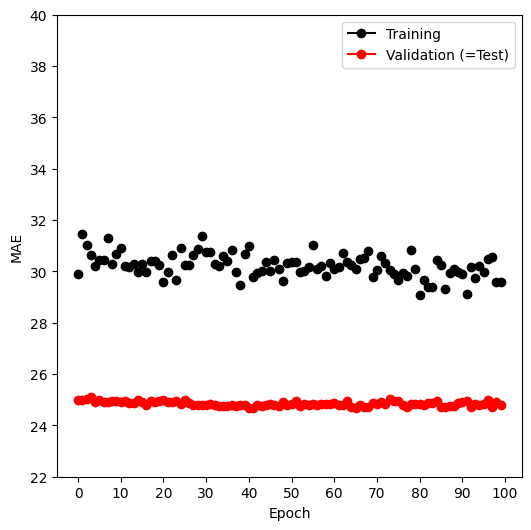

In [39]:
# Q1 Part D: Learning Curve & Interpretation
# Load training log from CSV file saved during training
from matplotlib.pyplot import subplots
import os


def summary_plot(results,
                 ax,
                 col='loss',
                 valid_legend='Validation',
                 training_legend='Training',
                 ylabel='Loss',
                 fontsize=20): # Function to plot training and validation metrics over epochs. 
    for (column,
         color,
         label) in zip([f'train_{col}_epoch',
                        f'valid_{col}'],
                       ['black',
                        'red'],
                       [training_legend,
                        valid_legend]): # Iterate over training and validation metrics to plot them.
        results.plot(x='epoch',
                     y=column,
                     label=label,
                     marker='o',
                     color=color,
                     ax=ax) # Plot the specified metric for training and validation.
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    return ax



logger_results = pd.read_csv(logger.experiment.metrics_file_path) # Load the logged training metrics from the CSV file into a DataFrame.
fig, ax = subplots(1, 1, figsize=(6, 6))
ax = summary_plot(logger_results,
                  ax,
                  col='mae',
                  ylabel='MAE',
                  valid_legend='Validation (=Test)') # Plot the Mean Absolute Error (MAE) over epochs for training and validation datasets.
ax.set_ylim([22, 40]) # Set the y-axis limits for better visualization.
ax.set_xticks(np.linspace(0, 100, 11).astype(int)); # Set x-axis ticks from 0 to 100 in 11 steps
# Use the logger's experiment.metrics_file_path to get the correct version path

# Extract training and validation MAE across epochs
# PyTorch Lightning logs training metrics as 'train_mae_epoch' and validation as 'valid_mae'

#Interpretation (print the whole thing cleanly)
print("\nInterpretation:    ")      


In [ ]:
# Q2 Part A: Data Preparation - Load image dataset
# Define image transformations following ISLP conventions

# Compose chains multiple transformations together
transform = transforms.Compose([
    transforms.Resize((64, 64)),              # Resize all images to 64x64 pixels
    transforms.ToTensor(),                     # Convert PIL Image to tensor (0-1 range)
    transforms.Normalize(mean=[0.5, 0.5, 0.5], # Normalize each RGB channel
                        std=[0.5, 0.5, 0.5])   # to range [-1, 1]
])


###Load datasets using ImageFolder
from torchvision import datasets
from torchvision.io import read_image
from torchvision.datasets import ImageFolder
from torchvision.models import (resnet50,
                                ResNet50_Weights)
from torchvision.transforms import (Resize,
                                    Normalize,
                                    CenterCrop,
                                    ToTensor)


# ImageFolder expects structure: root/class_name/image_files


# It automatically assigns labels: 0 for first folder (cats), 1 for second (dogs)



train_path = 'cats_vs_dogs_dataset/train'
test_path = 'cats_vs_dogs_dataset/test'

train_image_dataset = datasets.ImageFolder(root=train_path, transform=transform)
test_image_dataset = datasets.ImageFolder(root=test_path, transform=transform)

# Create DataLoaders for batch processing
# shuffle=True randomizes training data order each epoch (prevents learning order)
# shuffle=False for test set (order doesn't matter for evaluation)

# Relevant Prints

# Get one batch to verify shapes + print 


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'cats_vs_dogs_dataset/train'

In [ ]:
# Q2 Part A (continued): Display 6 sample images with labels
# Helper function to denormalize images for display
# Our normalization: (x - 0.5) / 0.5, so to reverse: x * 0.5 + 0.5
def denormalize(tensor):
    """Convert normalized tensor back to [0, 1] range for visualization"""
    return tensor * 0.5 + 0.5

# Get a batch of images and labels

# Create figure with 2 rows, 3 columns

#Loop to denormalize and plot 

plt.suptitle('Sample Images from Cats vs Dogs Dataset', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('sample_images.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Sample images displayed and saved to 'sample_images.png'")


In [ ]:
# Q2 Part A (continued): Convert to TensorDataset format
# SimpleDataModule expects TensorDatasets, so we convert from ImageFolder format

# Extract all images and labels from ImageFolder datasets
def dataset_to_tensors(dataset):
    """Convert ImageFolder dataset to tensors"""
    images_list = []
    labels_list = []
    
    # Create a DataLoader to batch process
    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    
    # Get all data in one batch
    for images, labels in loader:
        images_list.append(images)
        labels_list.append(labels)
    
    return torch.cat(images_list), torch.cat(labels_list)

print("Converting datasets to tensors...")
train_images, train_labels = dataset_to_tensors(train_image_dataset)
test_images, test_labels = dataset_to_tensors(test_image_dataset)

# Create TensorDatasets
train_tensor_dataset = TensorDataset(train_images, train_labels)
test_tensor_dataset = TensorDataset(test_images, test_labels)

# Create SimpleDataModule with 25% validation split

# This will automatically split training data into train/validation

#Relevant Prints

# Verify batch shape from DataModule

#Relevant Prints 


In [ ]:
# Q2 Part B: Model Definition - Convolutional Neural Network
class CatDogCNN(nn.Module):
    """
    Convolutional Neural Network for binary image classification.
    
    Architecture:
      Conv Block 1:
        - Conv2d: 3→16 channels, 3×3 kernel, padding=1 (preserves size)
        - ReLU activation
        - MaxPool2d: 2×2 (reduces spatial size by half: 64×64 → 32×32)
      
      Conv Block 2:
        - Conv2d: 16→32 channels, 3×3 kernel, padding=1
        - ReLU activation
        - MaxPool2d: 2×2 (reduces size: 32×32 → 16×16)
      
      Fully Connected Layers:
        - Flatten: 32×16×16 = 8192 → flattened vector
        - Linear: 8192 → 128 neurons
        - ReLU activation
        - Dropout: 30% regularization
        - Linear: 128 → 2 (output logits for 2 classes)
    
    Why CNNs for images?
      - Convolutional layers detect spatial patterns (edges, textures, shapes)
      - Pooling layers reduce dimensionality while preserving features
      - Local connectivity exploits spatial structure unlike fully connected layers
    """
 

In [ ]:

# Instantiate the model

# Test with one batch + print output shape 

#Print model summary

# Print detailed model summary



In [ ]:
# Q2 Part C: Training - Train the CNN classifier

# Create Adam optimizer with learning rate of 0.001 as specified
from torch.optim import Adam

# Create SimpleModule for classification
# num_classes=2: binary classification (cat vs dog)
# SimpleModule.classification() automatically uses:
#   - loss_fn: CrossEntropyLoss (standard for classification)
#   - metrics: Accuracy (percentage of correct predictions)

# Setup logging

# Create Trainer for CNN

# Train the CNN

# Evaluate on test set

# Extract and report test accuracy (rounded to 2 decimal places)



In [ ]:
# Q2 Part D: Learning Curve & Interpretation
# Load CNN training log from CSV file saved during training

# Extract training and validation accuracy

# PyTorch Lightning logs training accuracy as 'train_accuracy_epoch' and validation as 'valid_accuracy'

# Create learning curve plot

# Interpretation (print the whole thing cleanly)
print("\nInterpretation:")
